In [12]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

X_train shape: (1106, 30, 1)
X_test shape : (120, 30, 1)


c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 30, 150)        │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,665 (1.06 MB)

 Trainable params: 276,665 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.1011 - val_loss: 0.0079
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.1011 - val_loss: 0.0079
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0042 - val_loss: 0.0074
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0042 - val_loss: 0.0074
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0029 - val_loss: 0.0046
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0029 - val_loss: 0.0046
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0026 - val_loss: 0.0033
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0026 - val_loss: 0.0033
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0026 - val_loss: 0.0082
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0026 - val_loss: 0.0082
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0027

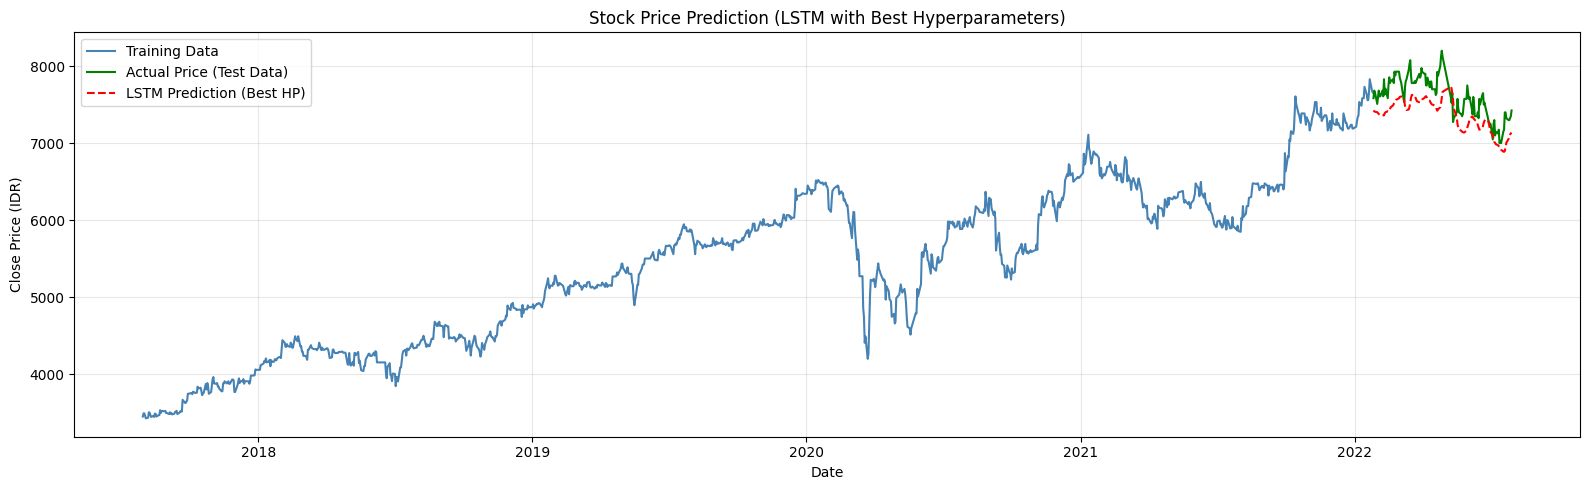

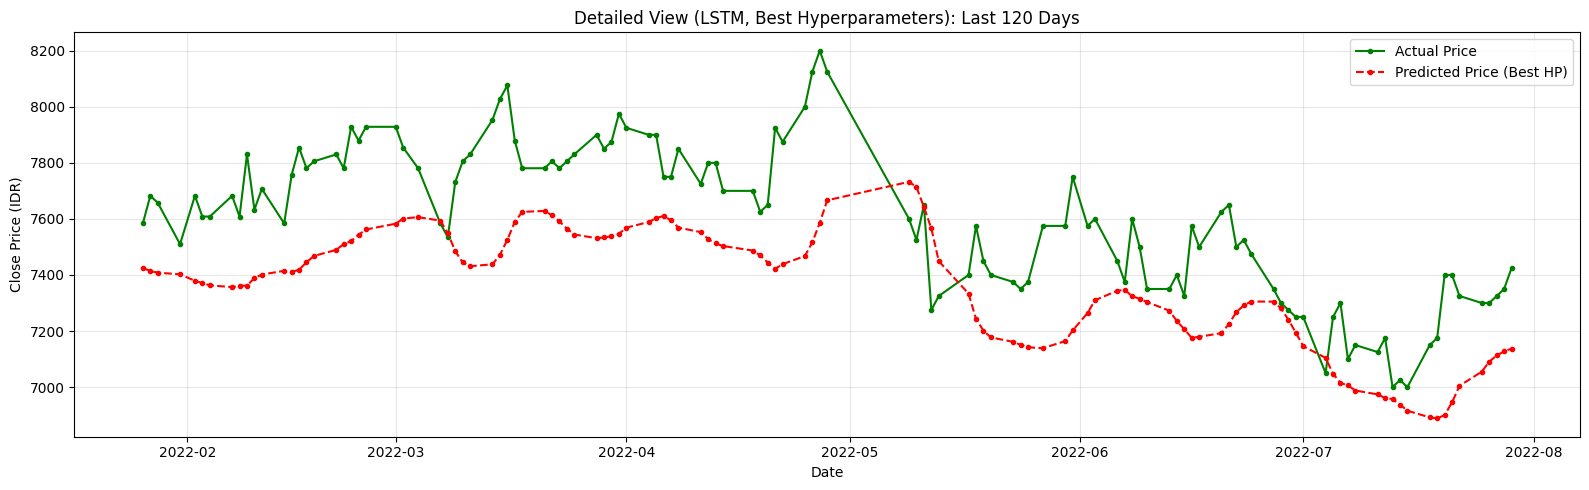

In [13]:
# ================================
# 2. Reproducibility (optional but good)
# ================================
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

# ================================
# 3. Hyperparameters (best found)
# ================================
SEQ_LEN       = 30      # lookback window
UNITS         = 150     # LSTM units
DROPOUT       = 0.2
BATCH_SIZE    = 32
LEARNING_RATE = 0.0005
EPOCHS        = 30
TEST_SIZE     = 120     # last 120 days as test

# ================================
# 4. Load and prepare data
# ================================
file_path = "CS-IDX30 version 3/CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx"

df_raw = pd.read_excel(file_path)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

# Use only Date + Close
df = df_raw[['Date', 'Close']].copy()
df.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)

# Ensure numeric and handle missing values
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df['y'] = df['y'].interpolate(method='linear')  # or .ffill().bfill()

# Convert to numpy for scaling
prices = df['y'].values.reshape(-1, 1)

# ================================
# 5. Train–test split (in original scale)
# ================================
train_size = len(prices) - TEST_SIZE
train_prices = prices[:train_size]
test_prices  = prices[train_size - SEQ_LEN:]  # include overlap for lookback

# ================================
# 6. Scaling (fit only on train to avoid leakage)
# ================================
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_prices)
test_scaled  = scaler.transform(test_prices)

# ================================
# 7. Helper to create sequences
# ================================
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test,  y_test  = create_sequences(test_scaled,  SEQ_LEN)

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

# ================================
# 8. Build LSTM model (using best HP)
# ================================
model = Sequential([
    LSTM(UNITS, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(DROPOUT),
    LSTM(UNITS, return_sequences=False),
    Dropout(DROPOUT),
    Dense(32, activation='relu'),
    Dense(1)  # next scaled price
])

optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='mean_squared_error')

model.summary()

# ================================
# 9. Train model
# ================================
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

# ================================
# 10. Make predictions on test set
# ================================
scaled_pred = model.predict(X_test)

# Inverse transform to original price scale
pred_prices = scaler.inverse_transform(scaled_pred).flatten()

# True prices and dates for the last TEST_SIZE days
y_true = df['y'].iloc[-TEST_SIZE:].values
test_dates = df['ds'].iloc[-TEST_SIZE:].values

print("len(y_true):", len(y_true), "len(pred_prices):", len(pred_prices))

# ================================
# 11. Metrics: MAE, RMSE + %
# ================================
y_true = np.array(y_true, dtype=float)
y_pred = np.array(pred_prices, dtype=float)

valid_mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
y_true_valid = y_true[valid_mask]
y_pred_valid = y_pred[valid_mask]

print("Valid points for metrics:", len(y_true_valid), "out of", len(y_true))

MAE  = mean_absolute_error(y_true_valid, y_pred_valid)
RMSE = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
mean_price = np.mean(y_true_valid)

MAE_percent  = (MAE  / mean_price) * 100
RMSE_percent = (RMSE / mean_price) * 100

print("\n===== LSTM Performance Metrics (Last 120 Days) =====")
print(f"MAE  : {MAE:,.2f}   ({MAE_percent:.2f}%)")
print(f"RMSE : {RMSE:,.2f}   ({RMSE_percent:.2f}%)")

# ================================
# 12. Build series for plotting
# ================================
train_actual = df.iloc[:-TEST_SIZE].copy()
test_actual  = df.iloc[-TEST_SIZE:].copy()

pred_series = pd.DataFrame({
    'ds': test_dates,
    'yhat_lstm': y_pred_valid  # predictions for last TEST_SIZE days
})

# ================================
# 13. Plot – full history
# ================================
plt.figure(figsize=(16, 5))

plt.plot(train_actual['ds'], train_actual['y'],
         label='Training Data', color='steelblue')

plt.plot(test_actual['ds'], test_actual['y'],
         label='Actual Price (Test Data)', color='green')

plt.plot(pred_series['ds'], pred_series['yhat_lstm'],
         'r--', label='LSTM Prediction (Best HP)')

plt.title('Stock Price Prediction (LSTM with Best Hyperparameters)')
plt.xlabel('Date')
plt.ylabel('Close Price (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ================================
# 14. Plot – zoomed last 120 days
# ================================
plt.figure(figsize=(16, 5))

plt.plot(test_actual['ds'], test_actual['y'],
         'g.-', label='Actual Price')
plt.plot(pred_series['ds'], pred_series['yhat_lstm'],
         'r.--', label='Predicted Price (Best HP)')

plt.title('Detailed View (LSTM, Best Hyperparameters): Last 120 Days')
plt.xlabel('Date')
plt.ylabel('Close Price (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
